# **Build Your First AI Agent**

### 🩺 **Medical RAG-Based AI Agent with Web Search**

##### **1. Setup and Prerequisites**

In [ ]:
# Install OpenAI SDK
!pip install -q U openai

In [ ]:
import os
from getpass import getpass

# OPENAI_API_KEY = getpass("Enter your OpenAI API Key: ")
# print(f"{OPENAI_API_KEY[:10]} ...")

os.environ["OPENAI_API_KEY"] = ""

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = ""

In [ ]:
!pip install -q langchain openai langchain-openai langchain_community chromadb pandas requests langchain-chroma

##### **2. Data Loading and Preprocessing**

In [ ]:
import pandas as pd

In [ ]:
!gdown 1FpC7_DaxWQJf4JoVQLlbSYcSTZSz86C6
df = pd.read_csv(r"ai-medical-chatbot.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1FpC7_DaxWQJf4JoVQLlbSYcSTZSz86C6
From (redirected): https://drive.google.com/uc?id=1FpC7_DaxWQJf4JoVQLlbSYcSTZSz86C6&confirm=t&uuid=3c493e59-b015-4967-ba49-ee4c02eea32e
To: /content/ai-medical-chatbot.csv
100% 267M/267M [00:04<00:00, 64.2MB/s]


In [ ]:
df.head()

,Description,Patient,Doctor
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...
3,Q. Why do I have uncomfortable feeling between...,"Hello doctor,I am having an uncomfortable feel...",Hello. The popping and discomfort what you fel...
4,Q. My symptoms after intercourse threatns me e...,"Hello doctor,Before two years had sex with a c...",Hello. The HIV test uses a finger prick blood ...


In [ ]:
# Combine the fields into one document for embedding
df['document'] = (
    df['Description'].fillna('') + '\n\n' +
    'Patient: ' + df['Patient'].fillna('') + '\n\n' +
    'Doctor: ' + df['Doctor'].fillna('')
)

df.head()

,Description,Patient,Doctor,document
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...,Q. What does abutment of the nerve root mean?\...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...,Q. What should I do to reduce my weight gained...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...,Q. I have started to get lots of acne on my fa...
3,Q. Why do I have uncomfortable feeling between...,"Hello doctor,I am having an uncomfortable feel...",Hello. The popping and discomfort what you fel...,Q. Why do I have uncomfortable feeling between...
4,Q. My symptoms after intercourse threatns me e...,"Hello doctor,Before two years had sex with a c...",Hello. The HIV test uses a finger prick blood ...,Q. My symptoms after intercourse threatns me e...


In [ ]:
print(df['document'][0])

Q. What does abutment of the nerve root mean?

Patient: Hi doctor,I am just wondering what is abutting and abutment of the nerve root means in a back issue. Please explain. What treatment is required for annular bulging and tear?

Doctor: Hi. I have gone through your query with diligence and would like you to know that I am here to help you. For further information consult a neurologist online -->


##### **3. Vector Store Initialization**

In [ ]:
# from langchain_chroma import Chroma
# from langchain_openai import OpenAIEmbeddings
# from langchain_core.documents import Document  # Updated import path
# import os

# # Initialize the embedding model
# embeddings = OpenAIEmbeddings(
#     model="text-embedding-3-small",
#     openai_api_key=os.environ.get("OPENAI_API_KEY")
# )

# # Set up the vector store
# PERSIST_DIR = "chroma_db"

# if os.path.exists(PERSIST_DIR) and os.listdir(PERSIST_DIR):
#     # Load existing DB if it exists
#     vectorstore = Chroma(
#         persist_directory=PERSIST_DIR,
#         embedding_function=embeddings
#     )
#     print("✅ Loaded existing vector store")
# else:
#     # Create documents from the dataframe
#     documents = [
#         Document(page_content=row['document'])
#         for _, row in df.head(75).iterrows()
#     ]

#     # Create and persist new DB
#     vectorstore = Chroma.from_documents(
#         documents=documents,
#         embedding=embeddings,
#         persist_directory=PERSIST_DIR
#     )
#     # Note: persist() is called automatically in newer versions
#     print(f"✅ Created new vector store with {len(documents)} documents")

# # Set up retriever
# retriever = vectorstore.as_retriever()
# print(f"✅ Retriever ready with {vectorstore._collection.count()} documents")

from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
import os
import shutil

# Initialize embeddings
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=os.environ.get("OPENAI_API_KEY")
)

# Use a different directory or ensure proper permissions
PERSIST_DIR = "./chroma_db_new"  # Changed to relative path with different name

# Complete cleanup - remove old database
if os.path.exists(PERSIST_DIR):
    try:
        shutil.rmtree(PERSIST_DIR)
        print(f"🗑️ Removed old database at {PERSIST_DIR}")
    except Exception as e:
        print(f"⚠️ Could not remove directory: {e}")
        # Try alternative directory
        PERSIST_DIR = f"./chroma_db_{os.getpid()}"
        print(f"Using alternative directory: {PERSIST_DIR}")

# Create directory with proper permissions
os.makedirs(PERSIST_DIR, exist_ok=True)
print(f"📁 Created directory: {PERSIST_DIR}")

# Verify DataFrame
if 'df' not in locals() and 'df' not in globals():
    raise ValueError("❌ DataFrame 'df' not found")

print(f"📊 DataFrame has {len(df)} rows")

# Create documents
documents = [
    Document(
        page_content=str(row['document']).strip(),  # Clean the text
        metadata={"index": idx, "source": "medical_qa"}
    )
    for idx, row in df.head(75).iterrows()
    if row['document'] and str(row['document']).strip()  # Skip empty documents
]

print(f"📄 Created {len(documents)} valid documents")
print(f"Sample: {documents[0].page_content[:150]}...")

# Create vector store with error handling
try:
    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embeddings,
        persist_directory=PERSIST_DIR,
        collection_name="medical_docs"  # Explicit collection name
    )

    # Verify creation
    all_data = vectorstore.get()
    doc_count = len(all_data['ids']) if all_data.get('ids') else 0
    print(f"✅ Successfully created vector store with {doc_count} documents")

    # Setup retriever
    retriever = vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 4}
    )

    # Test retrieval
    test_query = "nerve root abutment"
    test_results = retriever.invoke(test_query)
    print(f"✅ Test query '{test_query}' returned {len(test_results)} results")
    if test_results:
        print(f"Top result: {test_results[0].page_content[:100]}...")

except Exception as e:
    print(f"❌ Error creating vector store: {e}")
    print(f"Error type: {type(e).__name__}")

    # If it's still a permission error, try in-memory mode
    if "readonly" in str(e).lower():
        print("\n⚠️ Trying in-memory vector store (non-persistent)...")

        vectorstore = Chroma.from_documents(
            documents=documents,
            embedding=embeddings,
            # No persist_directory = in-memory only
            collection_name="medical_docs_memory"
        )

        doc_count = len(vectorstore.get()['ids'])
        print(f"✅ Created in-memory vector store with {doc_count} documents")
        print("⚠️ Note: This will not persist between sessions")

        retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

📁 Created directory: ./chroma_db_new
📊 DataFrame has 256916 rows
📄 Created 75 valid documents
Sample: Q. What does abutment of the nerve root mean?

Patient: Hi doctor,I am just wondering what is abutting and abutment of the nerve root means in a back ...
✅ Successfully created vector store with 75 documents
✅ Test query 'nerve root abutment' returned 4 results
Top result: Q. What does abutment of the nerve root mean?

Patient: Hi doctor,I am just wondering what is abutti...


In [ ]:
vectorstore._collection.count()

75

##### **4. Building the Retrieval-Augmented Generation (RAG) Chain**

In [ ]:
from langchain_classic.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain
from langchain_openai import ChatOpenAI
from langchain_classic.tools import Tool
import os


# Define the system prompt that will guide the chatbot
system_prompt = (
    "You are a helpful medical assistant. Answer the user's question based on the context provided below. "
    "If the context contains relevant information, use it to provide a clear answer. "
    "If you cannot find the answer in the context, simply say you don't have that information. "
    "Be concise and helpful."
    "\n\n"
    "{context}"
)

# Create a chat prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}")
])

# Initialize the LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2, openai_api_key=os.environ.get("OPENAI_API_KEY"))

# Create the RAG chain
question_answer_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)


def rag_context_tool(user_input):
    try:
      rag_response = rag_chain.invoke({"input": user_input})
      return rag_response.get("answer", "Sorry, no RAG answer found.")
    except Exception as e:
      return f"Error retrieving RAG context: {e}"

rag_context_tool = Tool(
    name="RAG Context Retriever",
    func=rag_context_tool,
    description="Retrieves relevant RAG context given user input and chat history."
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain
from langchain_openai import ChatOpenAI
from langchain.tools import tool  # Use @tool decorator instead of Tool class
import os

# Define the system prompt that will guide the chatbot
system_prompt = (
    "You are a helpful medical assistant. Answer the user's question based on the context provided below. "
    "If the context contains relevant information, use it to provide a clear answer. "
    "If you cannot find the answer in the context, simply say you don't have that information. "
    "Be concise and helpful."
    "\n\n"
    "{context}"
)

# Create a chat prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}")
])

# Initialize the LLM
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2,
    api_key=os.environ.get("OPENAI_API_KEY")
)

# Create the RAG chain
question_answer_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)

# Define the tool using @tool decorator (v1 style)
@tool
def rag_context_tool(user_input: str) -> str:
    """Retrieves relevant medical context from the knowledge base given user input.

    Args:
        user_input: The user's medical question or query

    Returns:
        A relevant answer based on the medical knowledge base
    """
    try:
        rag_response = rag_chain.invoke({"input": user_input})
        return rag_response.get("answer", "Sorry, no RAG answer found.")
    except Exception as e:
        return f"Error retrieving RAG context: {str(e)}"

# Test the tool
print("✅ RAG tool created successfully")

# Example usage
if __name__ == "__main__":
    test_query = "What is nerve root abutment?"
    result = rag_context_tool.invoke(test_query)
    print(f"\nTest Query: {test_query}")
    print(f"Answer: {result[:200]}...")

✅ RAG tool created successfully

Test Query: What is nerve root abutment?
Answer: Nerve root abutment refers to a condition where a structure, such as a herniated disc or bone spur, comes into contact with or presses against a nerve root in the spine. This can lead to symptoms such...


In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver

# Create agent with built-in memory
agent = create_agent(
    model="gpt-4o-mini",
    tools=[rag_context_tool],
    system_prompt="You are a helpful medical assistant.",
    checkpointer=MemorySaver()  # Enables conversation memory
)

# Chat with memory (use same thread_id for conversation continuity)
config = {"configurable": {"thread_id": "conversation-1"}}

# First message
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is nerve root abutment?"}]},
    config=config
)
print(response["messages"][-1].content)

# Second message - remembers context
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What are the symptoms?"}]},
    config=config
)
print(response["messages"][-1].content)

Nerve root abutment refers to a condition where a structure, such as a herniated disc or bone spur, is pressing against or making contact with a nerve root in the spine. This pressure can lead to symptoms such as pain, numbness, or weakness in the areas of the body that the affected nerve root supplies. It is often associated with conditions like spinal stenosis or disc herniation. For specific treatment options, consulting a healthcare professional is recommended.
The symptoms of nerve root abutment can vary depending on which nerve root is affected, but common symptoms may include:

1. **Pain**: Sharp or burning pain that radiates along the path of the nerve. This pain can often be felt in the back, neck, arms, or legs, depending on the location of the nerve root involvement.

2. **Numbness**: A loss of sensation or a tingling feeling in the areas supplied by the affected nerve.

3. **Weakness**: Muscle weakness in the areas innervated by the affected nerve, which can impact movement

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI

# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)

# Your tools
tools = [rag_context_tool]

# System prompt (replaces the ReAct template)
system_prompt = """You are a helpful medical assistant.

IMPORTANT RULES:
1. ALWAYS use the RAG Context Retriever tool to answer medical questions
2. Do NOT answer medical questions on your own without using the tool
3. If the question is non-medical, respond: "I'm not allowed to discuss it."
4. Base your answers ONLY on the information retrieved from the RAG tool
5. If the RAG tool returns no relevant information, say you don't have that information

Think step-by-step before answering."""

# Create agent with memory
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt,
    checkpointer=MemorySaver()  # Replaces ConversationBufferMemory
)

print("✅ Agent created with memory")

# Usage with conversation tracking
config = {"configurable": {"thread_id": "medical-chat-1"}}

# Example conversation
response1 = agent.invoke(
    {"messages": [{"role": "user", "content": "What is nerve root abutment?"}]},
    config=config
)
print("Response 1:", response1["messages"][-1].content)

# Continues the conversation (remembers context)
response2 = agent.invoke(
    {"messages": [{"role": "user", "content": "What are the treatment options?"}]},
    config=config
)
print("Response 2:", response2["messages"][-1].content)

✅ Agent created with memory
Response 1: Nerve root abutment refers to a condition where a structure, such as a bulging disc or bone spur, comes into contact with or presses against a nerve root in the spine. This can lead to symptoms such as pain, numbness, or weakness in the areas of the body that the affected nerve root supplies. It is often associated with conditions like herniated discs or spinal stenosis. For specific treatment options, it's best to consult a healthcare professional.
Response 2: I don't have that information.


##### **5. Testing the RAG System**

In [ ]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "hi"}]},
    config={"configurable": {"thread_id": "medical-chat-1"}}
)
print(response["messages"][-1].content)

I'm not allowed to discuss it.


In [ ]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "what are the causes of chest pain"}]},
    config={"configurable": {"thread_id": "medical-chat-1"}}
)
print(response["messages"][-1].content)

Chest pain can have various causes, including:

1. **Cardiac Issues**: Conditions like angina, heart attack, or pericarditis can cause chest pain. Cardiac pain is often severe and may radiate to the left arm.

2. **Gastrointestinal Problems**: Acid reflux, esophagitis, or peptic ulcers can lead to chest pain that may mimic cardiac pain.

3. **Musculoskeletal Issues**: Strain or injury to the chest muscles, ribs, or cartilage can cause localized pain.

4. **Pulmonary Conditions**: Issues such as pneumonia, pleuritis, or pulmonary embolism can result in chest pain, often accompanied by breathing difficulties.

5. **Anxiety and Stress**: Panic attacks or anxiety can lead to chest pain, often described as sharp or tight.

6. **Other Causes**: Conditions like shingles or aortic dissection can also present with chest pain.

It's important to differentiate the type of chest pain and seek medical evaluation, especially if it is severe or accompanied by other symptoms like shortness of breath o

#  **RAG-Based AI Agent Evaluation**

#### 🧪 RAG Evaluation Workflow

A typical **Retrieval-Augmented Generation (RAG)** evaluation workflow consists of **three main steps**:

---

## 1️⃣ Create a Dataset

Prepare a dataset that includes:

- A set of **questions**
- Their corresponding **expected (ground truth) answers**

This dataset serves as the benchmark for evaluating your RAG system.

---

## 2️⃣ Run Your RAG Application

Use the dataset to:

- Feed questions into your **RAG pipeline**
- Collect the generated responses for each question

---

## 3️⃣ Evaluate the Outputs

Use **evaluation metrics and tools** to assess the performance based on:

- ✅ **Answer Relevance**: Is the answer useful and contextually appropriate?
- 🎯 **Answer Accuracy**: Does the answer correctly match the ground truth?
- 📚 **Retrieval Quality**: Are the retrieved documents relevant and supportive of the answer?

---


In [ ]:
!pip install -q -U langsmith

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.1/413.1 kB 6.2 MB/s eta 0:00:00


In [ ]:
from langsmith import Client, evaluate
from langsmith.evaluation import LangChainStringEvaluator

# Initialize client
client = Client()

In [ ]:
# Create a simple wrapper function for evaluation
def predict(inputs):
    """Wrapper function that takes inputs and returns prediction"""
    response = agent_executor.invoke({"input": inputs["question"]})
    return {"answer": response["output"]}

#### **1. Evaluation Metrics**

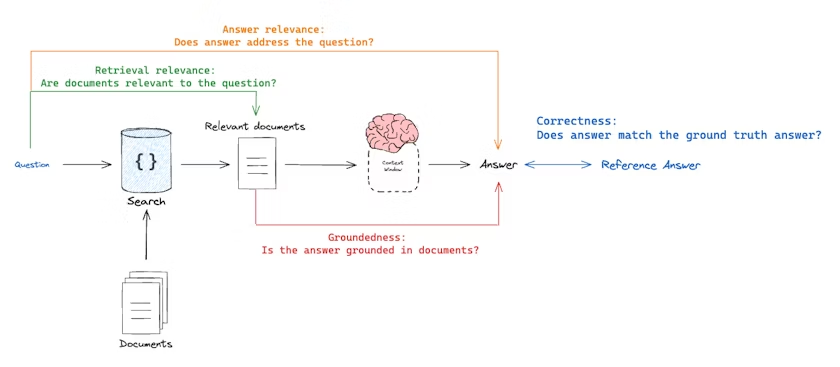

In [ ]:


from langsmith.evaluation import LangChainStringEvaluator, evaluate
from langchain_openai import ChatOpenAI

# Use LangSmith's built-in evaluators
evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Custom correctness evaluator using LangSmith
def correctness_evaluator(run, example):
    """Evaluate correctness by comparing prediction to reference."""
    evaluator = LangChainStringEvaluator(
        "qa",
        config={
            "criteria": {
                "correctness": """

        Consider the submission CORRECT (Y) if:
          • Main facts align with the reference answer
          • Core meaning is the same (even if worded differently)
          • No significant factual errors
          • Both refuse to answer (different refusal wording is OK)
          • Minor paraphrasing or reasonable additions are acceptable

        Consider the submission INCORRECT (N) if:
          • Contains factual errors or contradicts reference
          • Misses key information from reference
          • Provides answer when should refuse (or vice versa)
          • Significantly different meaning from reference

        Special cases for medical chatbot:
        - "I don't have information" ≈ "I'm not allowed to discuss it" → CORRECT
        - Both refuse to answer = CORRECT (semantically equivalent)
        - One provides info, one refuses = INCORRECT (mismatch)

        Focus on semantic equivalence, not exact word matching.
        """
            },
            "llm": evaluator_llm
        }
    )

    result = evaluator.evaluate_run(run, example)
    return result

print("✅ LangSmith evaluator created")

✅ LangSmith evaluator created


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import json

evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", """Evaluate hallucination (0.0-1.0 scale, higher is better):
0.0-0.3: Severe fabrication
0.4-0.6: Moderate mix
0.7-0.8: Minor issues
0.9-1.0: No hallucination

Return JSON: {{"score": 0.0-1.0, "reasoning": "explanation"}}"""),
    ("user", "Question: {input}\nAnswer: {prediction}\n\nEvaluate:")
])

def evaluate_hallucination(prediction: str, input: str) -> dict:
    response = (hallucination_prompt | evaluator_llm).invoke({
        "prediction": prediction,
        "input": input
    })
    try:
        result = json.loads(response.content)
        return {"score": max(0.0, min(1.0, float(result["score"]))), "reasoning": result["reasoning"]}
    except:
        return {"score": 0.5, "reasoning": response.content}

print("✅ Hallucination evaluator ready")

✅ Hallucination evaluator ready


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import json

evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", """Evaluate if the answer is RELEVANT to the question.

RELEVANT (Y): Directly addresses question, on-topic, helpful
IRRELEVANT (N): Off-topic, misses main point, generic/unrelated

Return JSON: {{"score": "Y" or "N", "reasoning": "brief explanation"}}"""),
    ("user", "Question: {input}\nAnswer: {prediction}\n\nEvaluate:")
])

def evaluate_relevance(prediction: str, input: str) -> dict:
    response = (relevance_prompt | evaluator_llm).invoke({
        "prediction": prediction,
        "input": input
    })
    try:
        result = json.loads(response.content)
        return {"score": 1 if result["score"] == "Y" else 0, "reasoning": result["reasoning"]}
    except:
        score = 1 if "y" in response.content.lower() or "relevant" in response.content.lower() else 0
        return {"score": score, "reasoning": response.content}

print("✅ Relevance evaluator ready")

✅ Relevance evaluator ready


#### 2. **Evaluation Dataset**

In [ ]:
# CREATE EVALUATION DATASET

# Sample test cases with ground truth answers
evaluation_dataset = [
    {
        "question": "What are the causes of chest pain?",
        "ground_truth": "Chest pain can be caused by cardiac issues, gastrointestinal problems, musculoskeletal issues, or pulmonary conditions."
    },
    {
        "question": "What does abutment of nerve root mean?",
        "ground_truth": "Abutment of nerve root refers to compression or contact with the nerve root in spinal conditions."
    },
    {
        "question": "How to treat acne?",
        "ground_truth": "Acne treatment includes topical medications, oral medications, lifestyle changes, and proper skincare."
    },
    {
        "question": "What is Diabtese?",
        "ground_truth": "I don't have context about this."
    }
]

In [ ]:
# Create dataset in LangSmith
dataset_name = "medical-chatbot-eval"

In [ ]:
try:
    # Try to create new dataset
    dataset = client.create_dataset(dataset_name)

    # Add examples to dataset
    for example in evaluation_dataset:
        client.create_example(
            inputs={"question": example["question"]},
            outputs={"answer": example["ground_truth"]},
            dataset_id=dataset.id
        )
    print(f"Created dataset: {dataset_name}")
except Exception as e:
    print(f"Dataset might already exist: {e}")
    # Use existing dataset
    dataset = client.read_dataset(dataset_name=dataset_name)

Created dataset: medical-chatbot-eval


In [ ]:
def predict(inputs):
    """Wrapper function for agent predictions."""
    response = agent.invoke(
        {"messages": [{"role": "user", "content": inputs["question"]}]},
        config={"configurable": {"thread_id": "eval-thread"}}
    )
    return {"answer": response["messages"][-1].content}

print("✅ Prediction wrapper created")


✅ Prediction wrapper created


#### **3. Run Evaluation**

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import json

evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [ ]:
# Define custom evaluator functions
correctness_prompt = ChatPromptTemplate.from_messages([
    ("system", """Evaluate correctness (Y/N):
CORRECT (Y): Main facts align, same core meaning, no significant errors
INCORRECT (N): Factual errors, misses key info, wrong meaning

Special: Both refusing = CORRECT
Return JSON: {{"score": "Y" or "N", "reasoning": "explanation"}}"""),
    ("user", "Question: {input}\nReference: {reference}\nPrediction: {prediction}\n\nEvaluate:")
])

def evaluate_correctness_custom(prediction: str, reference: str, input: str) -> dict:
    response = (correctness_prompt | evaluator_llm).invoke({
        "prediction": prediction,
        "reference": reference,
        "input": input
    })
    try:
        result = json.loads(response.content)
        return {"score": 1 if result["score"] == "Y" else 0, "reasoning": result["reasoning"]}
    except:
        score = 1 if "y" in response.content.lower() else 0
        return {"score": score, "reasoning": response.content}

In [ ]:
def evaluate_hallucination_custom(prediction: str, input: str) -> dict:
    response = (hallucination_prompt | evaluator_llm).invoke({
        "prediction": prediction,
        "input": input
    })
    try:
        result = json.loads(response.content)
        return {"score": max(0.0, min(1.0, float(result["score"]))), "reasoning": result["reasoning"]}
    except:
        return {"score": 0.5, "reasoning": response.content}

In [ ]:
def evaluate_relevance_custom(prediction: str, input: str) -> dict:
    response = (relevance_prompt | evaluator_llm).invoke({
        "prediction": prediction,
        "input": input
    })
    try:
        result = json.loads(response.content)
        return {"score": 1 if result["score"] == "Y" else 0, "reasoning": result["reasoning"]}
    except:
        score = 1 if "y" in response.content.lower() else 0
        return {"score": score, "reasoning": response.content}

print("✅ Custom evaluators created")

✅ Custom evaluators created


In [ ]:
from langsmith import evaluate

print("\n" + "="*50)
print("RUNNING RAG EVALUATION")
print("="*50 + "\n")

# Run evaluation with LangSmith
results = evaluate(
    predict,
    data=dataset_name,
    evaluators=[],  # LangSmith will handle evaluation
    experiment_prefix="medical-chatbot-eval-v1",
    metadata={
        "model": "gpt-4o-mini",
        "version": "1.0",
        "framework": "langchain-v1"
    }
)

print("\n✅ Evaluation complete!")
print(f"Results: {results}")


RUNNING RAG EVALUATION

View the evaluation results for experiment: 'medical-chatbot-eval-v1-518967f1' at:
https://smith.langchain.com/o/51ca90e2-651a-43f6-b0ad-01cc4f6b29e2/datasets/7ff04453-1900-420e-9a77-1177bf80abf6/compare?selectedSessions=2472516f-d1f9-4f1a-a961-bc2ee1f2f6c7




0it [00:00, ?it/s]


✅ Evaluation complete!
Results: <ExperimentResults medical-chatbot-eval-v1-518967f1>


In [ ]:
print("\n" + "="*50)
print("TESTING INDIVIDUAL EVALUATION")
print("="*50 + "\n")

# Test with a single example
test_question = "What are the causes of chest pain?"
test_response = agent.invoke(
    {"messages": [{"role": "user", "content": test_question}]},
    config={"configurable": {"thread_id": "test-eval"}}
)

agent_answer = test_response["messages"][-1].content
print(f"Question: {test_question}")
print(f"\nAgent Response: {agent_answer}")

# Evaluate this response
print("\n--- Correctness Evaluation ---")
correctness_result = evaluate_correctness_custom(
    prediction=agent_answer,
    reference="Chest pain can be caused by cardiac issues, gastrointestinal problems, musculoskeletal issues, or pulmonary conditions.",
    input=test_question
)
print(f"Score: {correctness_result['score']}")
print(f"Reasoning: {correctness_result['reasoning']}")

print("\n--- Hallucination Check ---")
hallucination_result = evaluate_hallucination_custom(
    prediction=agent_answer,
    input=test_question
)
print(f"Score: {hallucination_result['score']:.2f}/1.0")
print(f"Reasoning: {hallucination_result['reasoning']}")

print("\n--- Relevance Check ---")
relevance_result = evaluate_relevance_custom(
    prediction=agent_answer,
    input=test_question
)
print(f"Score: {relevance_result['score']}")
print(f"Reasoning: {relevance_result['reasoning']}")

print("\n✅ Individual evaluation complete!")


TESTING INDIVIDUAL EVALUATION

Question: What are the causes of chest pain?

Agent Response: Chest pain can have various causes, including:

1. **Cardiac Causes**: 
   - Angina (reduced blood flow to the heart)
   - Myocardial infarction (heart attack)
   - Pericarditis (inflammation of the heart lining)

2. **Gastrointestinal Causes**: 
   - Acid reflux (GERD)
   - Esophageal spasms
   - Peptic ulcers

3. **Musculoskeletal Causes**: 
   - Costochondritis (inflammation of the rib cartilage)
   - Muscle strain
   - Rib fractures

4. **Pulmonary Causes**: 
   - Pulmonary embolism (blood clot in the lungs)
   - Pneumonia
   - Pleuritis (inflammation of the lung lining)

5. **Anxiety and Stress**: 
   - Panic attacks can cause chest pain and discomfort.

It's important to differentiate between these causes, especially to rule out serious cardiac issues. If you experience chest pain, it's advisable to seek medical attention.

--- Correctness Evaluation ---
Score: 1
Reasoning: The predictio